# Unit13 Example 03 - 化工案例一：二氧化硫溶解度模式

本 Notebook 以 **9 組實驗數據** 示範如何進行化工單位換算，建構線性設計矩陣，並以最小平方法估計 $\mathrm{SO_2}$ 溶解度模式 $x = ap + b\sqrt{p}$ 中的未知參數。

## 學習目標
- 執行化工單位換算：mmHg → atm；g-SO₂/100g-H₂O → 莫耳分率
- 識別模式 $x = ap + b\sqrt{p}$ 為參數線性模式，建構設計矩陣 $\mathbf{A} = [\,p,\ \sqrt{p}\,]$
- 使用 `scipy.linalg.lstsq()` 求解最小平方問題
- 計算誤差平方和 $J$ 以評估模式擬合品質
- 繪製分壓 vs. 莫耳分率之實驗數據與模式擬合曲線

---
### 0. 環境設定

In [14]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit13_Example_03'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit13'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit13
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit13\outputs\Unit13_Example_03
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit13\outputs\Unit13_Example_03\figs


---
### 1. 載入套件

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from scipy.linalg import lstsq

# 繪圖樣式設定
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'lines.linewidth': 2,
    'axes.unicode_minus': False,
})

print("✓ 套件載入完成")
import scipy
print(f"  numpy      版本: {np.__version__}")
print(f"  scipy      版本: {scipy.__version__}")
import matplotlib
print(f"  matplotlib 版本: {matplotlib.__version__}")

✓ 套件載入完成
  numpy      版本: 1.23.5
  scipy      版本: 1.15.2
  matplotlib 版本: 3.10.8


---
### 2. 問題描述

**化工背景：** 二氧化硫（ $\mathrm{SO_2}$ ）在水中的溶解度模式在工業廢氣洗滌塔設計中至關重要。在 $15^\circ\mathrm{C}$ 下，溶解度模式為：

$$
x = a p + b \sqrt{p}
$$

其中 $x$ 為水溶液中 $\mathrm{SO_2}$ 之莫耳分率（無因次）， $p$ 為氣相分壓（atm）， $a, b$ 為待估計參數。

**實驗數據（原始單位）：**

| $p_{\mathrm{SO_2}}$ (mmHg) | 0.3 | 0.8 | 2.2 | 3.8 | 5.7 | 10.0 | 19.3 | 28.0 | 44.0 |
|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|
| $C_w$ (g-SO₂/100g-H₂O) | 0.02 | 0.05 | 0.10 | 0.15 | 0.20 | 0.30 | 0.50 | 0.70 | 1.00 |

> **注意：** 模式中的 $p$ 單位為 atm，$x$ 為莫耳分率，需先完成單位換算。

---
### 3. 單位換算

**分壓換算：** $p\ (\mathrm{atm}) = p_{\mathrm{SO_2}}\ (\mathrm{mmHg})\ /\ 760$

**莫耳分率換算：**

$$
x = \frac{C_w / M_{\mathrm{SO_2}}}{C_w / M_{\mathrm{SO_2}} + 100 / M_{\mathrm{H_2O}}}
$$

其中 $M_{\mathrm{SO_2}} = 64\ \mathrm{g/mol}$ ， $M_{\mathrm{H_2O}} = 18\ \mathrm{g/mol}$ 。

In [16]:
# ==========================================
# 3. 單位換算
# ==========================================

# 原始實驗數據
p_SO2_mmHg = np.array([0.3, 0.8, 2.2, 3.8, 5.7, 10.0, 19.3, 28.0, 44.0])
Cw_g       = np.array([0.02, 0.05, 0.10, 0.15, 0.20, 0.30, 0.50, 0.70, 1.00])

# 分子量
M_SO2  = 64.0   # g/mol
M_H2O  = 18.0   # g/mol

# 壓力換算: mmHg → atm
p = p_SO2_mmHg / 760.0

# 莫耳分率換算
n_SO2  = Cw_g / M_SO2             # SO2 莫耳數 (per 100 g H2O)
n_H2O  = 100.0 / M_H2O            # H2O 莫耳數
x      = n_SO2 / (n_SO2 + n_H2O)  # SO2 莫耳分率

# 列印換算結果
print("換算後數據 (9 組實驗點):")
print(f"{'p_SO2 (mmHg)':>14} {'Cw (g/100g)':>12} {'p (atm)':>12} {'x (莫耳分率)':>16}")
print("-" * 58)
for i in range(len(p)):
    print(f"{p_SO2_mmHg[i]:>14.1f} {Cw_g[i]:>12.2f} {p[i]:>12.6f} {x[i]:>16.6e}")

換算後數據 (9 組實驗點):
  p_SO2 (mmHg)  Cw (g/100g)      p (atm)         x (莫耳分率)
----------------------------------------------------------
           0.3         0.02     0.000395     5.624684e-05
           0.8         0.05     0.001053     1.406052e-04
           2.2         0.10     0.002895     2.811709e-04
           3.8         0.15     0.005000     4.216971e-04
           5.7         0.20     0.007500     5.621838e-04
          10.0         0.30     0.013158     8.430387e-04
          19.3         0.50     0.025395     1.404275e-03
          28.0         0.70     0.036842     1.964882e-03
          44.0         1.00     0.057895     2.804612e-03


---
### 4. 建構設計矩陣與最小平方求解

對模式 $x = ap + b\sqrt{p}$ ，設計矩陣 $\mathbf{A}$ 的兩行分別為 $p$ 與 $\sqrt{p}$ （無常數項）：

$$
\mathbf{A} =
\begin{bmatrix}
p_1 & \sqrt{p_1} \\
p_2 & \sqrt{p_2} \\
\vdots & \vdots \\
p_9 & \sqrt{p_9}
\end{bmatrix}, \quad
\mathbf{B} =
\begin{bmatrix} x_1 \\ x_2 \\ \vdots \\ x_9 \end{bmatrix}
$$

最小平方解：

$$
\begin{bmatrix} a \\ b \end{bmatrix} = \left(\mathbf{A}^T \mathbf{A}\right)^{-1} \mathbf{A}^T \mathbf{B}
$$

In [17]:
# ==========================================
# 4. 建構設計矩陣與最小平方求解
# ==========================================

# 設計矩陣: A = [p, sqrt(p)]  (無常數項)
A = np.column_stack([p, np.sqrt(p)])
B = x.copy()

print("設計矩陣 A (前5行):")
print(f"{'p':>14} {'sqrt(p)':>14}")
print("-" * 30)
for i in range(5):
    print(f"{A[i, 0]:>14.6e} {A[i, 1]:>14.6e}")
print("...")

# 使用 scipy.linalg.lstsq 求解
theta, residuals, rank, sv = lstsq(A, B)
a_hat, b_hat = theta

print(f"\n設計矩陣秩 (rank) = {rank}")
print(f"\n{'='*50}")
print(f"      SO2 溶解度模式參數估計結果")
print(f"{'='*50}")
print(f" 模式: x = a*p + b*sqrt(p)")
print(f" a = {a_hat:.6f}")
print(f" b = {b_hat:.6f}")

# 計算誤差平方和
x_model = A @ theta
errors  = x - x_model
J       = np.sum(errors**2)
print(f" 誤差平方和 J = {J:.4e}")
print(f"{'='*50}")

設計矩陣 A (前5行):
             p        sqrt(p)
------------------------------
  3.947368e-04   1.986799e-02
  1.052632e-03   3.244428e-02
  2.894737e-03   5.380276e-02
  5.000000e-03   7.071068e-02
  7.500000e-03   8.660254e-02
...

設計矩陣秩 (rank) = 2

      SO2 溶解度模式參數估計結果
 模式: x = a*p + b*sqrt(p)
 a = 0.034395
 b = 0.003444
 誤差平方和 J = 2.7283e-09


---
### 5. 各數據點結果詳覽

In [18]:
# ==========================================
# 5. 各數據點結果詳覽
# ==========================================

print("各數據點結果:  (x 值均乘以 1e4 顯示)")
print(f"{'p (×1e-3 atm)':>16} {'x_exp (×1e-4)':>15} {'x_model (×1e-4)':>17} {'error (×1e-5)':>15}")
print("-" * 67)
for i in range(len(p)):
    print(f"{p[i]*1e3:>16.4f} {x[i]*1e4:>15.4f} {x_model[i]*1e4:>17.4f} {errors[i]*1e5:>15.3f}")

print(f"\n誤差平方和 J = {J:.4e}")
print(f"\n結論: 模式 x = {a_hat:.5f}*p + {b_hat:.5f}*sqrt(p) 對此組數據擬合良好")

各數據點結果:  (x 值均乘以 1e4 顯示)
   p (×1e-3 atm)   x_exp (×1e-4)   x_model (×1e-4)   error (×1e-5)
-------------------------------------------------------------------
          0.3947          0.5625            0.8200          -2.575
          1.0526          1.4061            1.4793          -0.733
          2.8947          2.8117            2.8484          -0.367
          5.0000          4.2170            4.1548           0.622
          7.5000          5.6218            5.5620           0.599
         13.1579          8.4304            8.4758          -0.455
         25.3947         14.0428           14.2223          -1.795
         36.8421         19.6488           19.2817           3.671
         57.8947         28.0461           28.1988          -1.527

誤差平方和 J = 2.7283e-09

結論: 模式 x = 0.03439*p + 0.00344*sqrt(p) 對此組數據擬合良好


---
### 6. 繪製擬合結果圖

繪製**分壓 $p$ (atm)** 對 **莫耳分率 $x$** 的實驗數據與模式擬合曲線比較圖。

✓ 圖檔已儲存: d:\MyGit\ChemE-3502\Unit13\outputs\Unit13_Example_03\figs\so2_solubility_fitting.png


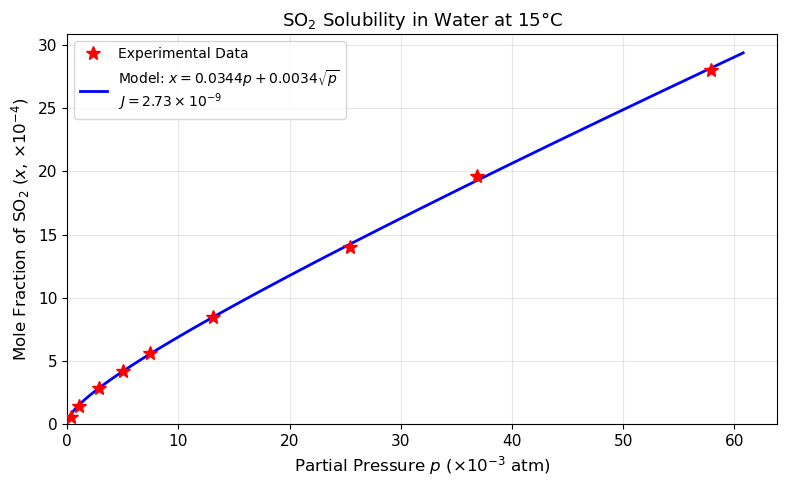

In [19]:
# ==========================================
# 6. 繪製擬合結果圖
# ==========================================

# 建立平滑曲線用的壓力點
p_plot  = np.linspace(0, p.max() * 1.05, 300)
x_fit   = a_hat * p_plot + b_hat * np.sqrt(p_plot)

fig, ax = plt.subplots(figsize=(8, 5))

# 繪製實驗數據點
ax.plot(p * 1e3, x * 1e4, 'r*', markersize=10, label='Experimental Data', zorder=5)

# 繪製模式擬合曲線
ax.plot(p_plot * 1e3, x_fit * 1e4, 'b-', linewidth=2,
        label=f'Model: $x = {a_hat:.4f}p + {b_hat:.4f}\\sqrt{{p}}$\n'
              r'$J = 2.73 \times 10^{-9}$')

ax.set_xlabel(r'Partial Pressure $p$ ($\times 10^{-3}$ atm)')
ax.set_ylabel(r'Mole Fraction of SO$_2$ ($x$, $\times 10^{-4}$)')
ax.set_title(r'SO$_2$ Solubility in Water at 15$\degree$C')
ax.legend(loc='upper left')
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

plt.tight_layout()
fig_path = FIG_DIR / 'so2_solubility_fitting.png'
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
print(f"✓ 圖檔已儲存: {fig_path}")
plt.show()

---
### 7. 結語

本範例完成以下工作流程：

| 步驟 | 內容 | 工具 |
|------|------|------|
| 單位換算 | mmHg → atm；g/100g → 莫耳分率 | `numpy` 向量運算 |
| 設計矩陣 | $\mathbf{A} = [p,\ \sqrt{p}]$ ，無常數項 | `numpy.column_stack()` |
| 參數估計 | 線性最小平方法 | `scipy.linalg.lstsq()` |
| 結果驗證 | 計算 $J$ 值與各點殘差 | `numpy` |
| 視覺化 | 實驗數據 vs. 擬合曲線 | `matplotlib` |

**估計結果：** 模式 $x = 0.03440\,p + 0.00344\,\sqrt{p}$ （ $J = 2.73 \times 10^{-9}$ ）對 $15^\circ\mathrm{C}$ 下 $\mathrm{SO_2}$ 在水中的溶解度具有良好的描述能力。

---

**課程資訊**
- 課程名稱：電腦在化工上之應用 (ChemE 3502)
- 課程單元：Unit13 參數估計 — 範例三
- 課程製作：逢甲大學 化工系 智慧程序系統工程實驗室
- 授課教師：莊曜禎 助理教授
- 更新日期：2026-02-28

**課程授權 [CC BY-NC-SA 4.0]**
本教材遵循 [創用CC 姓名標示-非商業性-相同方式分享 4.0 國際 (CC BY-NC-SA 4.0)](https://creativecommons.org/licenses/by-nc-sa/4.0/deed.zh) 授權。